# Notebook 03 — SmallCNN on CIFAR-10

**Note:** Training all 5 seeds takes ~20–40 min per seed on CPU; ~5 min per seed on GPU. Set `USE_CACHED=True` after first run to skip expensive steps.

**Architecture-specific extras in §2:** conv kernel visualisation, spatial activation maps, class×path heatmap.

**Ablation in §3:** BFT vs magnitude vs random comparative sweep + causal circuit ablation.

**Stimulus analysis in §4:** NNLS round-trip, ID sanity check, near-OOD (CIFAR-100), far-OOD (4 synthetic 3-channel types).

## §0 — Imports & Config

In [1]:
%matplotlib inline
import sys, os, pickle, copy, warnings, time
from collections import defaultdict
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from sklearn.metrics.pairwise import paired_cosine_distances
from torch.utils.data import DataLoader, TensorDataset

from src import (
    SmallCNN,
    load_experiment, save_experiment, get_transform, get_loaders_from_config,
    collect_layer_dicts,
    bft,
    build_scaffold_edges, scaffold_loading_from_edges, scaffold_layer_sizes_from_edges, plot_scaffold_graph,
    extract_tree_nodes, compute_node_activations, plot_factor_tree,
    extract_factor_fingerprint, extract_fingerprint_matrix,
    compute_stimulus_similarity, project_stimuli_onto_tree,
    extract_factor_tree_nodes, compute_factor_activations,
    nodes_at_layer, top_stimuli_factor_activations,
    select_class_circuit, per_class_accuracy,
    plot_factor_overview_panel, plot_factor_gallery, plot_input_layer_factors,
    plot_pruning_results, plot_embedding_comparison,
    compute_nmf_stability, plot_nmf_stability_figure,
    compute_k_sensitivity, plot_k_sensitivity_figure,
    plot_robustness_summary,
)

plt.rcParams.update({'figure.dpi': 80})
DEVICE = ('cuda' if torch.cuda.is_available() else
           'mps'  if torch.backends.mps.is_available() else 'cpu')
print('device:', DEVICE)

device: cuda


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
MODEL_ROOT = '../data/models'
CACHE_ROOT = '../data/cache/nb03_cnn'
FIG_DIR    = '../figs/03_cnn_cifar10'
DATA_DIR   = '../data'
os.makedirs(MODEL_ROOT, exist_ok=True)
os.makedirs(CACHE_ROOT, exist_ok=True)
os.makedirs(FIG_DIR,    exist_ok=True)

SEED_DIRS = [os.path.join(MODEL_ROOT, f'cifar10_cnn_seed{s}') for s in range(5)]

# ── CIFAR-10 constants ────────────────────────────────────────────────────────
CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                    'dog','frog','horse','ship','truck']
CLASS_NAMES     = {i: CIFAR10_CLASSES[i] for i in range(10)}
CIFAR10_MEAN    = (0.4914, 0.4822, 0.4465)
CIFAR10_STD     = (0.2470, 0.2435, 0.2616)
N_CLASSES       = 10
IMAGE_SIDE      = 32

# ── BFT hyperparameters ───────────────────────────────────────────────────────
K_MAX          = [6, 6, 6, 6, 10]
N_BRANCHES     = [1, 1, 1, 1, 5]
POOL_METHOD    = 'avg'
STIM_THRESHOLD = 0.0
N_TOP_PER_CLASS= 60

# ── Ablation ──────────────────────────────────────────────────────────────────
ABLATION_FRACS   = [0.02, 0.05, 0.10, 0.20, 0.30]
N_RANDOM_REPEATS = 10
N_SEEDS          = 5
USE_CACHED_ABL   = True

METHODS       = ['bft_top', 'bft_bottom', 'magnitude', 'random']
METHOD_COLORS = {'bft_top': 'red', 'bft_bottom': 'orange',
                 'magnitude': 'gray', 'random': 'black'}
METHOD_LABELS = {'bft_top': 'BFT most important', 'bft_bottom': 'BFT least important',
                 'magnitude': 'Highest magnitude', 'random': 'Random'}

# ── Stimulus analysis ─────────────────────────────────────────────────────────
TOP_N_FACTOR   = 50

print('Config ready')
print(f'SEED_DIRS: {SEED_DIRS}')

Config ready
SEED_DIRS: ['../data/models/cifar10_cnn_seed0', '../data/models/cifar10_cnn_seed1', '../data/models/cifar10_cnn_seed2', '../data/models/cifar10_cnn_seed3', '../data/models/cifar10_cnn_seed4']


## §1 — Models (5 seeds)

**Note:** Each seed takes ~20–40 min on CPU or ~5 min on GPU. Checkpoints are saved to `data/models/cifar10_cnn_seed{N}/` and reloaded on subsequent runs.

In [3]:
normalize   = T.Normalize(CIFAR10_MEAN, CIFAR10_STD)
train_tf    = T.Compose([T.RandomCrop(32, 4), T.RandomHorizontalFlip(), T.ToTensor(), normalize])
test_tf     = T.Compose([T.ToTensor(), normalize])
train_ds_aug = torchvision.datasets.CIFAR10(DATA_DIR, True,  download=True, transform=train_tf)
test_ds      = torchvision.datasets.CIFAR10(DATA_DIR, False, download=True, transform=test_tf)
train_loader = DataLoader(train_ds_aug, 128, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,      256, shuffle=False, num_workers=0)

BASE_CONFIG = {
    'arch': 'SmallCNN',
    'arch_kwargs': {'channels': [32, 64, 128, 256], 'n_classes': 10, 'global_pool': True},
    'dataset': 'CIFAR10',
    'dataset_kwargs': {'root': '../data/', 'batch_size': 128},
    'label_transform': 'identity',
}

models = []
for s, seed_dir in enumerate(SEED_DIRS):
    if os.path.isdir(seed_dir) and os.path.exists(os.path.join(seed_dir, 'weights.pt')):
        m, cfg = load_experiment(seed_dir, device=DEVICE)
        m.eval()
        with torch.no_grad():
            n_correct = sum(
                (m(x.to(DEVICE)).argmax(1) == y.to(DEVICE)).sum().item()
                for x, y in test_loader
            )
        acc = n_correct / len(test_ds)
        print(f'[seed {s}] loaded — test acc = {acc:.4f}')
    else:
        print(f'[seed {s}] training (this takes ~20-40 min on CPU) …')
        torch.manual_seed(s)
        m = SmallCNN(channels=[32, 64, 128, 256], n_classes=10, global_pool=True)
        m.to(DEVICE)
        N_EPOCHS = 150
        opt  = torch.optim.SGD(m.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
        sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS)
        crit = nn.CrossEntropyLoss()
        for ep in range(1, N_EPOCHS + 1):
            m.train()
            for x, y in train_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                opt.zero_grad()
                loss = crit(m(x), y); loss.backward(); opt.step()
            sch.step()
            if ep % 30 == 0 or ep == N_EPOCHS:
                m.eval()
                with torch.no_grad():
                    n_c = sum((m(x.to(DEVICE)).argmax(1) == y.to(DEVICE)).sum().item()
                               for x, y in test_loader)
                print(f'  ep {ep}: test acc = {n_c/len(test_ds):.4f}')
        cfg = dict(BASE_CONFIG)
        cfg['description'] = f'SmallCNN on CIFAR-10, seed {s}'
        save_experiment(m, cfg, seed_dir)
        print(f'[seed {s}] saved to {seed_dir}')
    models.append(m)

print('\nAll 5 seeds ready.')

[seed 0] loaded — test acc = 0.9030
[seed 1] loaded — test acc = 0.9001
[seed 2] loaded — test acc = 0.8987
[seed 3] loaded — test acc = 0.9006
[seed 4] loaded — test acc = 0.8975

All 5 seeds ready.


## §2 — Factorization & Inspection (seed 0)

In [4]:
model0, cfg0 = load_experiment(SEED_DIRS[0], device=DEVICE)
model0.eval()

def imdenorm(img, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    m = np.array(mean)[None, None, :]; s = np.array(std)[None, None, :]
    return np.clip(img.transpose(1, 2, 0) * s + m, 0, 1)

def confidence_filter(raw, top_k, n_classes=N_CLASSES):
    keep = np.sort(np.concatenate([
        np.where(raw['targets'] == c)[0][
            np.argsort(raw['confidences'][raw['targets'] == c])[::-1][:top_k]]
        for c in range(n_classes)]))
    images = raw['images'][keep]
    targets = raw['targets'][keep]
    layer_data = [{**ld, 'input_fmap': ld['input_fmap'][keep],
                   'output_fmap': ld['output_fmap'][keep]}
                   for ld in raw['layer_data']]
    return {'images': images, 'targets': targets,
            'confidences': raw['confidences'][keep],
            'layer_data': layer_data}, keep

# Collect layer data for seed 0
_p = os.path.join(CACHE_ROOT, 'raw_data_seed0.pkl')
if os.path.exists(_p):
    with open(_p, 'rb') as f:
        raw0 = pickle.load(f)
    print('Loaded raw layer data from cache')
else:
    print('Collecting layer data for seed 0 …')
    raw0 = collect_layer_dicts(model0, test_loader, DEVICE, only_correct=True)
    with open(_p, 'wb') as f:
        pickle.dump(raw0, f)
    print('Saved.')

data0, _ = confidence_filter(raw0, N_TOP_PER_CLASS)
all_images0  = data0['images']
all_targets0 = data0['targets']
layer_inputs0 = [ld['input_fmap'] for ld in data0['layer_data']]
n_samples0   = len(all_images0)
print(f'{n_samples0} samples after filter | layers: {[x.shape for x in layer_inputs0]}')

Loaded raw layer data from cache
600 samples after filter | layers: [(600, 3, 32, 32), (600, 32, 16, 16), (600, 64, 8, 8), (600, 128, 4, 4), (600, 256)]


In [5]:
# ── BFT (seed 0, layer-dict mode) ─────────────────────────────────────────────
_p = os.path.join(CACHE_ROOT, 'bft_seed0.pkl')
if os.path.exists(_p):
    with open(_p, 'rb') as f:
        tree_root0 = pickle.load(f)
    print('Loaded BFT tree from cache')
else:
    print('Running BFT (seed 0) …')
    tree_root0 = bft(
        data0['layer_data'],
        k_max=K_MAX, n_branches=N_BRANCHES,
        conv_pool_method=POOL_METHOD,
        stimulus_threshold=STIM_THRESHOLD,
        weighting='img_selectivity', verbose=1, n_jobs=3,
    )
    with open(_p, 'wb') as f:
        pickle.dump(tree_root0, f)
    print('BFT done and cached')

tree_nodes0   = extract_tree_nodes(tree_root0)
factor_nodes0 = extract_factor_tree_nodes(tree_root0)
l0_nodes0     = nodes_at_layer(tree_root0, 0)
print(f'Tree nodes: {len(tree_nodes0)}  factor nodes: {len(factor_nodes0)}')
print(f'Root factors: K={len(tree_root0["lambdas"])}')
print(f'L0 leaf nodes (first conv): {len(l0_nodes0)}')

Loaded BFT tree from cache
Tree nodes: 21  factor nodes: 127
Root factors: K=10
L0 leaf nodes (first conv): 5


In [6]:
# ── Plot 1+4: Factor overview panels & per-factor galleries (all tree nodes) ──
for node in tree_nodes0:
    layer_name = node.get('layer_name', f'L{node["layer_idx"]}')
    figs1 = plot_factor_overview_panel(node, all_images0, all_targets0, CLASS_NAMES)
    for k, fig in enumerate(figs1):
        fig.savefig(os.path.join(FIG_DIR, f'factor_overview_{layer_name}_k{k}.pdf'),
                    bbox_inches='tight')
        plt.close(fig)
    K = node['img_factors'].shape[1]
    for k in range(K):
        fig4 = plot_factor_gallery(node, all_images0, all_targets0, CLASS_NAMES, k=k, n=10)
        fig4.savefig(os.path.join(FIG_DIR, f'factor_gallery_{layer_name}_k{k}.pdf'),
                     bbox_inches='tight')
        plt.close(fig4)

print(f'Plot 1+4 saved for {len(tree_nodes0)} tree nodes.')

Plot 1+4 saved for 21 tree nodes.


In [7]:
# ── Plot 2: Input-layer spatial factors (conv_rgb for first-conv leaf nodes) ──
for leaf in l0_nodes0:
    figs2 = plot_input_layer_factors(leaf, all_images0, arch='conv_rgb',
                                      image_shape=(3, IMAGE_SIDE, IMAGE_SIDE))
    layer_name = leaf.get('layer_name', f'L{leaf["layer_idx"]}')
    for k, fig in enumerate(figs2):
        fig.savefig(os.path.join(FIG_DIR, f'input_factors_{layer_name}_k{k}.pdf'),
                    bbox_inches='tight')
        plt.close(fig)

print(f'Plot 2 saved for {len(l0_nodes0)} L0 leaf nodes.')

Plot 2 saved for 5 L0 leaf nodes.


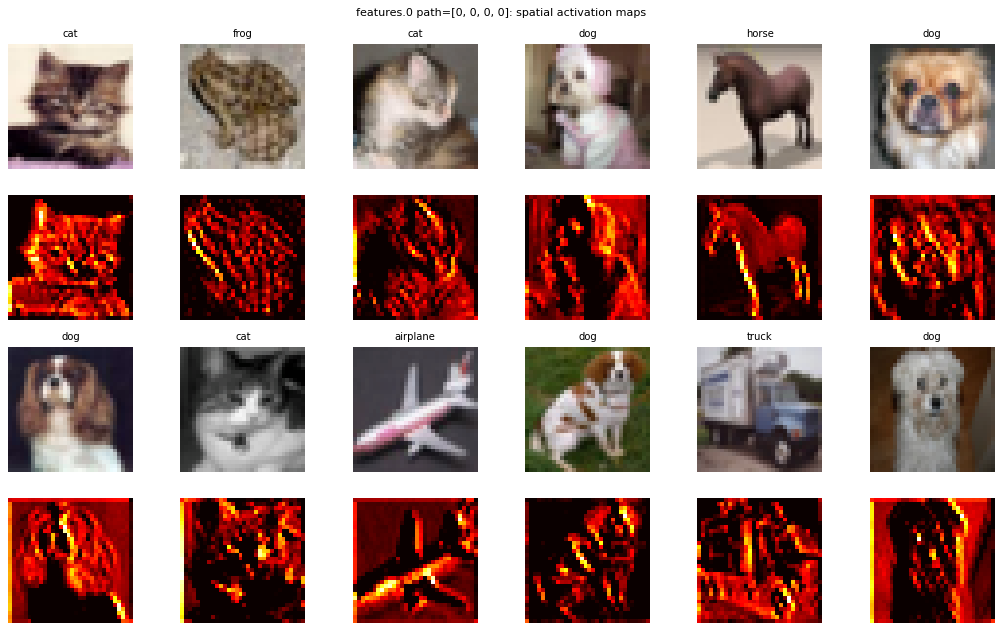

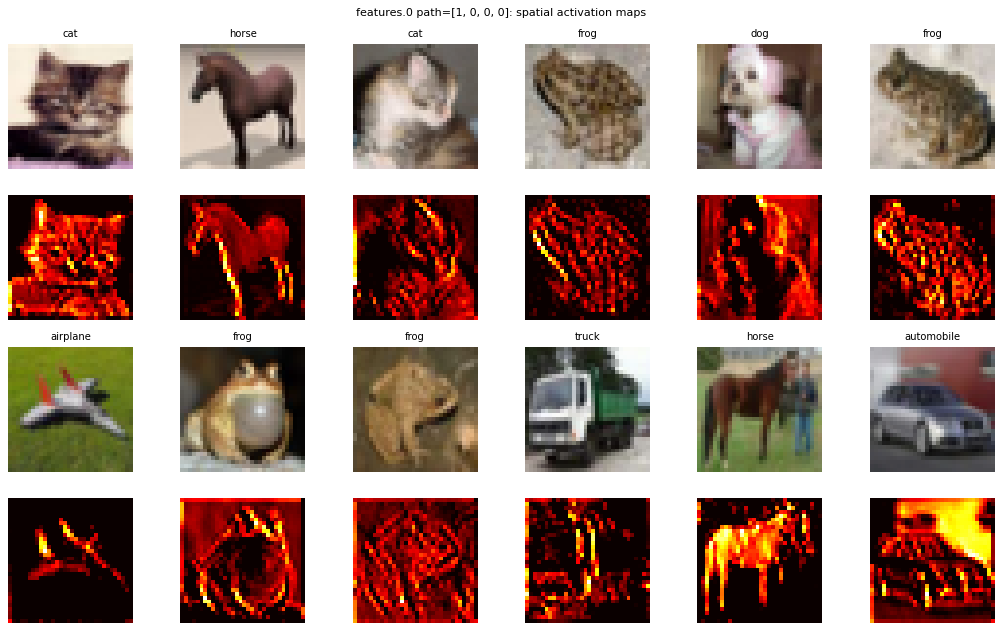

In [8]:
# ── Spatial activation maps (top conv layer in spine) ─────────────────────────
def get_spatial_activation_map(model, images_np, node, layer_data, device, n_images=6, which='top'):
    scores = node['img_factors'][:, 0]
    sel_idx = np.argsort(scores)[::-1][:n_images] if which == 'top' else np.argsort(scores)[:n_images]
    ld = layer_data[node['layer_idx']]
    C_out = ld['weight'].shape[0]; kH = ld['weight'].shape[2]; kW = ld['weight'].shape[3]
    C_in  = ld['weight'].shape[1]
    neu_f = node['neural_factors']
    ch_importance = np.maximum(neu_f[:, 0].reshape(C_out, C_in * kH * kW).sum(1), 0)
    if ch_importance.sum() > 0:
        ch_importance /= ch_importance.sum()

    feature_maps = {}
    target_mod = dict(model.named_modules())[node['layer_name']]
    hook = target_mod.register_forward_hook(
        lambda m, i, o: feature_maps.update({'out': o.detach().cpu()}))
    model.eval()
    with torch.no_grad():
        model(torch.from_numpy(images_np[sel_idx]).float().to(device))
    hook.remove()

    fmap    = feature_maps['out'].numpy()
    spatial = np.maximum((fmap * ch_importance[None, :, None, None]).sum(1), 0)
    return spatial, sel_idx

# Show for each conv leaf node in first 2 paths
_shown = 0
for leaf in l0_nodes0[:2]:
    if leaf['layer_type'] != 'conv':
        continue
    top_maps, top_idx = get_spatial_activation_map(model0, all_images0, leaf,
                                                     data0['layer_data'], DEVICE, 6, 'top')
    bot_maps, bot_idx = get_spatial_activation_map(model0, all_images0, leaf,
                                                     data0['layer_data'], DEVICE, 6, 'bottom')
    n = len(top_idx)
    fig, axes = plt.subplots(4, n, figsize=(2.2 * n, 8))
    for col in range(n):
        axes[0, col].imshow(imdenorm(all_images0[top_idx[col]]))
        axes[0, col].set_title(CIFAR10_CLASSES[all_targets0[top_idx[col]]], fontsize=9)
        axes[0, col].axis('off')
        axes[1, col].imshow(top_maps[col], cmap='hot'); axes[1, col].axis('off')
        axes[2, col].imshow(imdenorm(all_images0[bot_idx[col]]))
        axes[2, col].set_title(CIFAR10_CLASSES[all_targets0[bot_idx[col]]], fontsize=9)
        axes[2, col].axis('off')
        axes[3, col].imshow(bot_maps[col], cmap='hot'); axes[3, col].axis('off')
    axes[0, 0].set_ylabel('Top image'); axes[1, 0].set_ylabel('Top map')
    axes[2, 0].set_ylabel('Bot image'); axes[3, 0].set_ylabel('Bot map')
    fig.suptitle(f'{leaf["layer_name"]} path={leaf["path"]}: spatial activation maps', fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f'spatial_{leaf["layer_name"]}_path{leaf["path"]}.pdf'),
                bbox_inches='tight')
    plt.show()

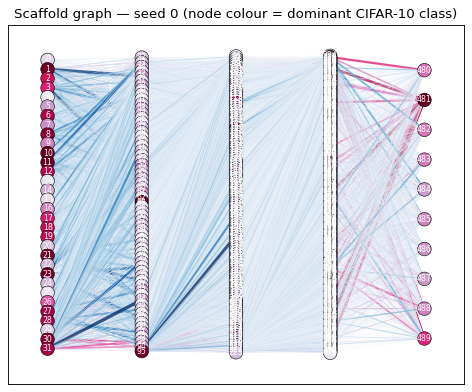

In [9]:
# ── Scaffold graph (seed 0) ───────────────────────────────────────────────────
def _get_spine(root):
    chain, node = [root], root
    while node["children"]:
        node = node["children"][0]; chain.append(node)
    return chain

spine = _get_spine(tree_root0)
layer_results = list(reversed(spine))          # forward order: input → output
edge_matrices, neg_edge_matrices = build_scaffold_edges(
    layer_results[1:], fi="path", fi_seed=layer_results[0], top_pct=0.05,
)
scaffold_loading = scaffold_loading_from_edges(edge_matrices)
layer_sizes = scaffold_layer_sizes_from_edges(edge_matrices)
fig = plot_scaffold_graph(scaffold_loading, edge_matrices, layer_sizes,
                          neg_edge_matrices=neg_edge_matrices)
fig.axes[0].set_title("Scaffold graph — seed 0 (node colour = dominant CIFAR-10 class)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "scaffold_seed0.pdf"), bbox_inches="tight")
plt.show()

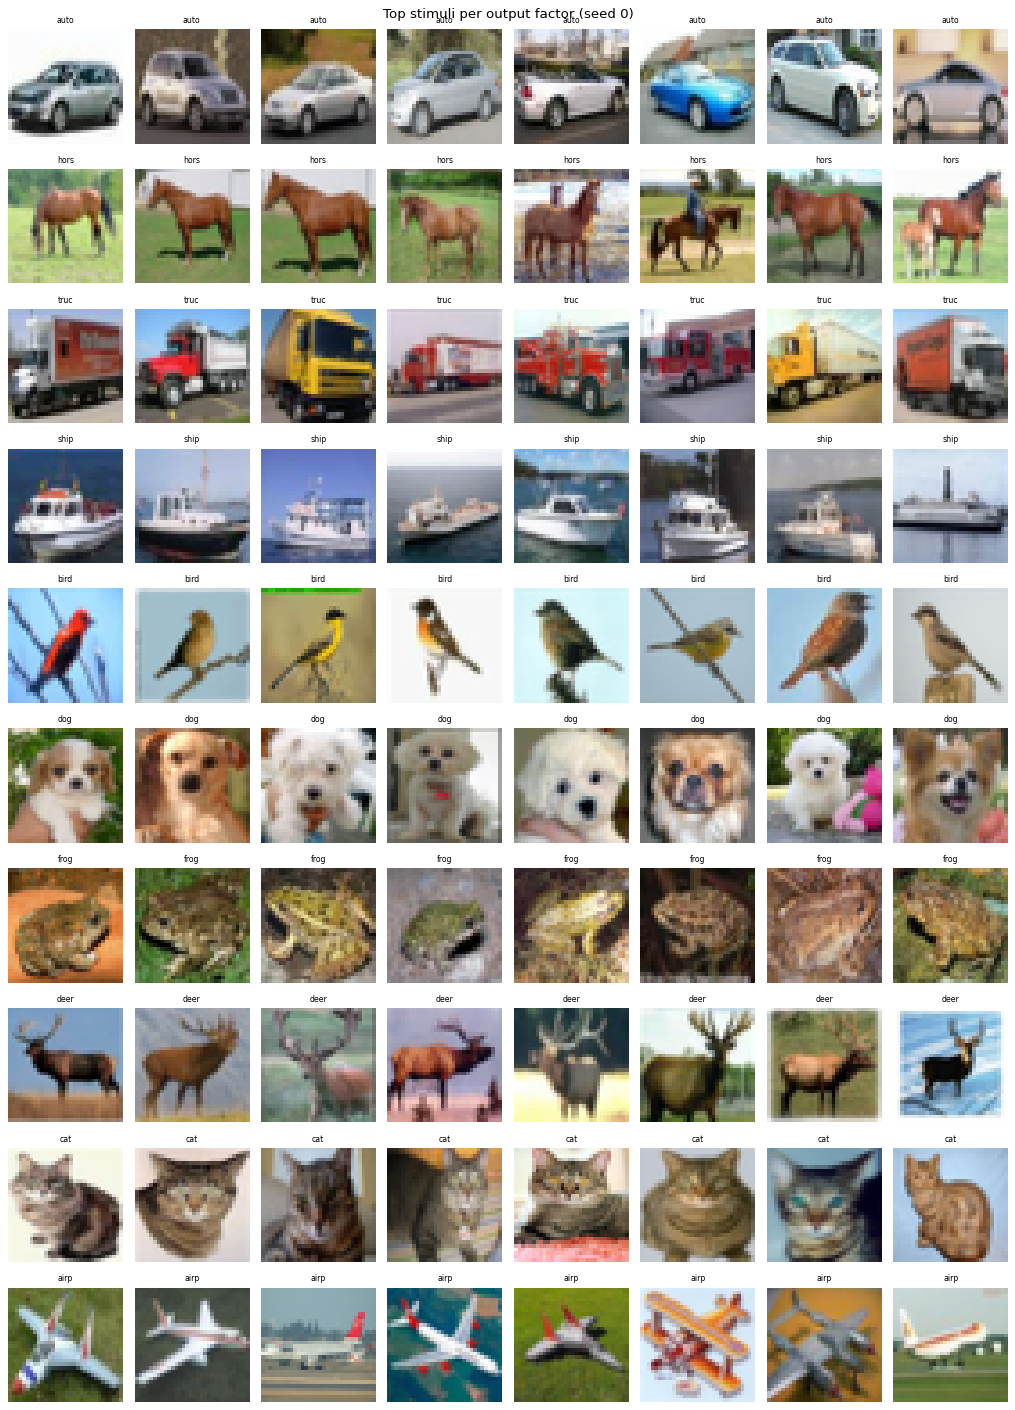

In [12]:
# ── Top-N stimulus gallery per output factor ──────────────────────────────────
K_root = tree_root0["img_factors"].shape[1]
N_GAL = 8
fig, axes = plt.subplots(K_root, N_GAL, figsize=(N_GAL * 1.6, K_root * 1.8))
for k in range(K_root):
    top_idx = np.argsort(tree_root0["img_factors"][:, k])[::-1][:N_GAL]
    for col, idx in enumerate(top_idx):
        axes[k, col].imshow(imdenorm(all_images0[idx]))
        axes[k, col].set_title(CIFAR10_CLASSES[all_targets0[idx]][:4], fontsize=7)
        axes[k, col].axis("off")
    axes[k, 0].set_ylabel(f"k={k} λ={tree_root0['lambdas'][k]:.2f}", fontsize=8,
                           rotation=0, labelpad=50, va="center")
plt.suptitle("Top stimuli per output factor (seed 0)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "top_stimuli_gallery.pdf"), bbox_inches="tight")
plt.show()

## §3 — Ablation (all 5 seeds)

For CNN, ablation uses named-parameter keys (`conv0.0.weight`, etc.) since `linear_layer_indices()` is MLP-specific.

In [13]:
# ── CNN ablation helpers ──────────────────────────────────────────────────────
def cnn_score_magnitude(layer_data):
    """Magnitude scores {(layer_idx, i, j): |W[i,j]|} for all layers."""
    scores = {}
    for l_idx, ld in enumerate(layer_data):
        W = ld['weight']
        flat = np.abs(W.reshape(W.shape[0], -1))
        for i in range(flat.shape[0]):
            for j in range(flat.shape[1]):
                scores[(l_idx, i, j)] = float(flat[i, j])
    return scores

def cnn_ablate_model(model, layer_data, scores, frac, method='top', seed=42):
    """Zero out `frac` fraction of weights by score. method in {'top','bottom','random'}."""
    all_vals = np.array(list(scores.values()))
    keys = list(scores.keys())
    n_ablate = max(1, int(round(len(keys) * frac)))
    if method == 'random':
        rng = np.random.RandomState(seed)
        ablate_keys = set(map(tuple, np.array(keys)[rng.permutation(len(keys))[:n_ablate]]))
    elif method == 'top':
        threshold = np.sort(all_vals)[::-1][n_ablate - 1]
        ablate_keys = {k for k, v in scores.items() if v >= threshold}
    else:
        threshold = np.sort(all_vals)[n_ablate - 1]
        ablate_keys = {k for k, v in scores.items() if v <= threshold}

    param_names = [name for name, _ in model.named_parameters()
                   if 'weight' in name and 'bn' not in name]
    abl = copy.deepcopy(model); abl.eval()
    state = abl.state_dict()
    for l_idx, ld in enumerate(layer_data):
        if l_idx >= len(param_names): break
        pname = param_names[l_idx]
        W = state[pname].clone()
        W_flat = W.reshape(W.shape[0], -1)
        for (li, i, j) in ablate_keys:
            if li == l_idx and i < W_flat.shape[0] and j < W_flat.shape[1]:
                W_flat[i, j] = 0.0
        state[pname] = W_flat.reshape(W.shape)
    abl.load_state_dict(state)
    return abl

print('CNN ablation helpers defined.')

CNN ablation helpers defined.


In [ ]:
# ── Plot 6: Ablation sweep — BFT vs magnitude vs random (all 5 seeds) ─────────
ABL_CACHE = os.path.join(CACHE_ROOT, 'plot6_ablation.pkl')

if USE_CACHED_ABL and os.path.exists(ABL_CACHE):
    with open(ABL_CACHE, 'rb') as f:
        pruning_raw = pickle.load(f)
    print(f'Loaded Plot 6 ablation from cache ({len(pruning_raw)} seeds).')
else:
    # pruning_raw[s][d][method][frac] = {class_id: acc}
    pruning_raw = []

    for s, seed_dir in enumerate(SEED_DIRS):
        print(f'\n=== Seed {s} ===')
        model_s, _ = load_experiment(seed_dir, device=DEVICE); model_s.eval()
        raw_s = collect_layer_dicts(model_s, test_loader, DEVICE, only_correct=True)
        data_s, _ = confidence_filter(raw_s, N_TOP_PER_CLASS)
        tgt_s = data_s['targets']

        # BFT with one branch per class at output for circuit identification
        n_br_abl = [1] * (len(K_MAX) - 1) + [N_CLASSES]
        _bft_p = os.path.join(CACHE_ROOT, f'bft_abl_seed{s}.pkl')
        if os.path.exists(_bft_p):
            with open(_bft_p, 'rb') as f: root_s = pickle.load(f)
        else:
            root_s = bft(data_s['layer_data'], k_max=K_MAX, n_branches=n_br_abl,
                          conv_pool_method=POOL_METHOD, stimulus_threshold=STIM_THRESHOLD, n_jobs=3)
            with open(_bft_p, 'wb') as f: pickle.dump(root_s, f)

        mag_scores = cnn_score_magnitude(data_s['layer_data'])
        seed_res = {d: {m: {f: {} for f in ABLATION_FRACS} for m in METHODS}
                    for d in range(N_CLASSES)}

        for d in range(N_CLASSES):
            print(f'  class {d} ({CIFAR10_CLASSES[d]})', end=' ', flush=True)
            imp_scores, _ = select_class_circuit(root_s, tgt_s, d)

            for frac in ABLATION_FRACS:
                # BFT top (most important weights first)
                abl = cnn_ablate_model(model_s, data_s['layer_data'], imp_scores, frac, 'top')
                seed_res[d]['bft_top'][frac] = per_class_accuracy(abl, test_loader, None, DEVICE)
                # BFT bottom (least important first — sanity check)
                abl = cnn_ablate_model(model_s, data_s['layer_data'], imp_scores, frac, 'bottom')
                seed_res[d]['bft_bottom'][frac] = per_class_accuracy(abl, test_loader, None, DEVICE)
                # Magnitude (highest |W| first)
                abl = cnn_ablate_model(model_s, data_s['layer_data'], mag_scores, frac, 'top')
                seed_res[d]['magnitude'][frac] = per_class_accuracy(abl, test_loader, None, DEVICE)
                # Random (mean over N_RANDOM_REPEATS draws)
                rand_accs = [per_class_accuracy(
                    cnn_ablate_model(model_s, data_s['layer_data'], imp_scores, frac, 'random', seed=rep),
                    test_loader, None, DEVICE)
                    for rep in range(N_RANDOM_REPEATS)]
                seed_res[d]['random'][frac] = {c: float(np.mean([a.get(c, 0) for a in rand_accs]))
                                               for c in range(N_CLASSES)}
            print('done')

        pruning_raw.append(seed_res)

    with open(ABL_CACHE, 'wb') as f:
        pickle.dump(pruning_raw, f)
    print('\nPlot 6 ablation complete and cached.')

# Aggregate across seeds → pruning_data[d][method][frac] = {class_id: mean_acc}
pruning_data = {d: {m: {f: {} for f in ABLATION_FRACS} for m in METHODS} for d in range(N_CLASSES)}
pruning_stds = {d: {m: {f: {} for f in ABLATION_FRACS} for m in METHODS} for d in range(N_CLASSES)}
for d in range(N_CLASSES):
    for m in METHODS:
        for f in ABLATION_FRACS:
            for c in range(N_CLASSES):
                vals = [pruning_raw[s][d][m][f].get(c, 0.0) for s in range(len(pruning_raw))]
                pruning_data[d][m][f][c] = float(np.mean(vals))
                pruning_stds[d][m][f][c] = float(np.std(vals))

print('Ablation aggregated. Classes:', list(pruning_data.keys()))


=== Seed 0 ===


/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterati

In [ ]:
# ── Causal ablation plots ─────────────────────────────────────────────────────
n_seeds_c = len(causal)
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
axes_flat = axes.flatten()

for d in range(N_CLASSES):
    ax = axes_flat[d]
    tgt_m, bys_m, tgt_s_arr, bys_s_arr = [], [], [], []
    for pct in PERCENTILES:
        t_vals = [causal[s][d]['baseline_accs'][d] - causal[s][d]['all_class_accs'][pct][d]
                   for s in range(n_seeds_c)]
        b_vals = [np.mean([causal[s][d]['baseline_accs'][c] - causal[s][d]['all_class_accs'][pct][c]
                            for c in range(N_CLASSES) if c != d]) for s in range(n_seeds_c)]
        tgt_m.append(np.mean(t_vals)); tgt_s_arr.append(np.std(t_vals))
        bys_m.append(np.mean(b_vals)); bys_s_arr.append(np.std(b_vals))
    ax.plot(PERCENTILES, tgt_m, 'r-o', lw=2, ms=5, label='Target')
    ax.fill_between(PERCENTILES, np.array(tgt_m) - np.array(tgt_s_arr),
                     np.array(tgt_m) + np.array(tgt_s_arr), alpha=0.2, color='r')
    ax.plot(PERCENTILES, bys_m, 'b--s', lw=2, ms=5, label='Bystander')
    ax.fill_between(PERCENTILES, np.array(bys_m) - np.array(bys_s_arr),
                     np.array(bys_m) + np.array(bys_s_arr), alpha=0.2, color='b')
    ax.axhline(0, color='gray', ls=':', alpha=0.5)
    ax.set_title(CIFAR10_CLASSES[d]); ax.set_xlabel('pct (%)')
    if d % 5 == 0: ax.set_ylabel('Accuracy drop')
    ax.set_ylim(-0.05, 1.0)
    if d == 0: ax.legend(fontsize=9)

plt.suptitle('Causal Circuit Ablation: accuracy drop vs importance threshold (CNN)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'causal_curves.pdf'), bbox_inches='tight')
plt.show()

# Specificity matrix
PCT_SPEC = 90
spec_mat = np.zeros((N_CLASSES, N_CLASSES))
for d in range(N_CLASSES):
    for c in range(N_CLASSES):
        spec_mat[d, c] = np.mean([causal[s][d]['baseline_accs'][c] -
                                   causal[s][d]['all_class_accs'][PCT_SPEC][c]
                                   for s in range(n_seeds_c)])

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(spec_mat, vmin=0, cmap='Reds')
plt.colorbar(im, ax=ax, label='Mean accuracy drop')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f'{spec_mat[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if spec_mat[i,j] > 0.35 else 'black')
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels([c[:4] for c in CIFAR10_CLASSES], rotation=45)
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels([c[:4] for c in CIFAR10_CLASSES])
ax.set_xlabel('Class affected (c)'); ax.set_ylabel('Circuit ablated (d)')
ax.set_title(f'Specificity matrix (pct={PCT_SPEC})')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'causal_specificity.pdf'), bbox_inches='tight')
plt.show()

# Wilcoxon test
tgt_90, bys_90 = [], []
for s in range(n_seeds_c):
    for d in range(N_CLASSES):
        base = causal[s][d]['baseline_accs']; abl = causal[s][d]['all_class_accs'][90]
        tgt_90.append(base[d] - abl[d])
        bys_90.append(np.mean([base[c] - abl[c] for c in range(N_CLASSES) if c != d]))
tgt_90 = np.array(tgt_90); bys_90 = np.array(bys_90)
diffs = tgt_90 - bys_90
stat, pval = wilcoxon(diffs, alternative='greater')
print(f'Wilcoxon H1: target_drop > bystander_drop  (n={len(diffs)} pairs)')
print(f'  Target:    {tgt_90.mean():.3f} ± {tgt_90.std():.3f}')
print(f'  Bystander: {bys_90.mean():.3f} ± {bys_90.std():.3f}')
print(f'  Δ={diffs.mean():.3f}  p={pval:.4f}')

## §4 — New Stimuli via NNLS

In [ ]:
# ── Round-trip test ───────────────────────────────────────────────────────────
N_RT = min(200, n_samples0)
rng_rt = np.random.default_rng(0)
rt_sub = rng_rt.choice(n_samples0, N_RT, replace=False)
rt_inputs = [l[rt_sub] for l in layer_inputs0]

projected_rt = project_stimuli_onto_tree(tree_root0, rt_inputs)
F_orig_rt    = extract_fingerprint_matrix(tree_root0, rt_sub)
F_rt         = extract_fingerprint_matrix(projected_rt, np.arange(N_RT))
rt_sims      = 1.0 - paired_cosine_distances(F_orig_rt, F_rt)
rt_root      = 1.0 - paired_cosine_distances(
    tree_root0['img_factors'][rt_sub], projected_rt['img_factors'])
print(f'Round-trip (full):  mean={rt_sims.mean():.4f}  std={rt_sims.std():.4f}')
print(f'Round-trip (root):  mean={rt_root.mean():.4f}  std={rt_root.std():.4f}')
print()
print('Active-sample fractions per node:')
for tn in tree_nodes0[:8]:  # show first 8 nodes
    sw = tn['stimulus_weights_in']
    print(f'  layer={tn["layer_idx"]}  path={tn["path"]}  active={(sw > 0.01).mean():.3f}')

In [ ]:
# ── ID sanity check (train set) ───────────────────────────────────────────────
train_ds_eval = torchvision.datasets.CIFAR10(DATA_DIR, True, download=True, transform=test_tf)
train_loader_eval = DataLoader(train_ds_eval, 256, shuffle=False, num_workers=0)

print('Collecting training set layer data …')
raw_train = collect_layer_dicts(model0, train_loader_eval, DEVICE, only_correct=True)
data_train, _ = confidence_filter(raw_train, N_TOP_PER_CLASS)
train_layer_inputs = [ld['input_fmap'] for ld in data_train['layer_data']]
train_targets = data_train['targets']
print(f'Training samples: {len(train_targets)}')

projected_train  = project_stimuli_onto_tree(tree_root0, train_layer_inputs)
factor_nodes_tr  = extract_factor_tree_nodes(projected_train)

# Cross-similarity matrix: 5 representative classes, train vs test
N_BLK = 50; SHOW_CL = [0, 1, 3, 7, 8]; rng_id = np.random.default_rng(42)
blocks = {}
for cl in SHOW_CL:
    tr_cl = np.where(train_targets == cl)[0]
    if len(tr_cl) > N_BLK: tr_cl = rng_id.choice(tr_cl, N_BLK, replace=False)
    blocks[f'tr-{CIFAR10_CLASSES[cl][:4]}'] = extract_fingerprint_matrix(projected_train, tr_cl)
    te_cl = np.where(all_targets0 == cl)[0]
    if len(te_cl) > N_BLK: te_cl = rng_id.choice(te_cl, N_BLK, replace=False)
    blocks[f'te-{CIFAR10_CLASSES[cl][:4]}'] = extract_fingerprint_matrix(tree_root0, te_cl)

F_cross = np.concatenate(list(blocks.values()), axis=0)
bl_sizes = [len(v) for v in blocks.values()]
bl_starts = [0] + list(np.cumsum(bl_sizes[:-1]))
bl_ends   = list(np.cumsum(bl_sizes))
S_cross   = compute_stimulus_similarity(F_cross)
centres   = np.array(bl_starts) + np.array(bl_sizes) / 2

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(S_cross, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine similarity')
for b in np.array(bl_ends[:-1]):
    ax.axhline(b - 0.5, color='k', lw=1.5); ax.axvline(b - 0.5, color='k', lw=1.5)
ax.set_xticks(centres); ax.set_xticklabels(list(blocks), rotation=45, ha='right', fontsize=8)
ax.set_yticks(centres); ax.set_yticklabels(list(blocks), fontsize=8)
ax.set_title('ID Sanity Check: train vs test cross-similarity (5 classes)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'id_cross_similarity.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Near-OOD: CIFAR-100 ────────────────────────────────────────────────────────
cifar100_test = torchvision.datasets.CIFAR100(
    DATA_DIR, train=False, download=True,
    transform=T.Compose([T.ToTensor(), normalize])  # apply CIFAR-10 normalisation
)
cifar100_loader = DataLoader(cifar100_test, 256, shuffle=False, num_workers=0)

print('Collecting CIFAR-100 layer data (OOD) …')
raw_ood = collect_layer_dicts(model0, cifar100_loader, DEVICE, only_correct=False)
ood_images  = raw_ood['images']
ood_targets = raw_ood['targets']  # CIFAR-100 class labels (0–99)
n_ood = len(ood_images)

# Model predictions (CIFAR-10 classes)
model0.eval()
ood_preds = np.concatenate([
    model0(x.to(DEVICE)).argmax(1).cpu().numpy()
    for x, _ in cifar100_loader
])

ood_layer_inputs = [ld['input_fmap'] for ld in raw_ood['layer_data']]
print(f'CIFAR-100 samples: {n_ood}')
print(f'Pred distribution: {dict(zip(*np.unique(ood_preds, return_counts=True)))}')

projected_ood  = project_stimuli_onto_tree(tree_root0, ood_layer_inputs)
factor_nodes_ood = extract_factor_tree_nodes(projected_ood)

# Factor tree per predicted CIFAR-10 class
fig, axes = plt.subplots(2, 5, figsize=(30, 8), squeeze=False)
for d in range(N_CLASSES):
    ax = axes[d // 5][d % 5]
    cl_idx = np.where(ood_preds == d)[0]
    acts = compute_factor_activations(factor_nodes_ood, cl_idx)
    plot_factor_tree(factor_nodes_ood, acts, ax=ax,
                     title=f'OOD→pred {CIFAR10_CLASSES[d]}\nn={len(cl_idx)}')
plt.suptitle('CIFAR-100 OOD — factor tree per predicted CIFAR-10 class', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'near_ood_trees.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Cross-similarity: ID CIFAR-10 vs CIFAR-100 ───────────────────────────────
N_BLOCK = 40; rng_blk = np.random.default_rng(2)
BLOCK_ID  = [0, 1, 7, 8]  # airplane, auto, horse, ship
BLOCK_C100 = [0, 10, 50, 90]  # a sample of CIFAR-100 classes

blocks_ood = {}
for cl in BLOCK_ID:
    idx = rng_blk.choice(np.where(all_targets0 == cl)[0],
                          min(N_BLOCK, (all_targets0 == cl).sum()), replace=False)
    blocks_ood[f'C10-{CIFAR10_CLASSES[cl][:4]}'] = extract_fingerprint_matrix(tree_root0, idx)
for c100 in BLOCK_C100:
    idx = np.where(ood_targets == c100)[0]
    if len(idx) == 0: continue
    idx = rng_blk.choice(idx, min(N_BLOCK, len(idx)), replace=False)
    blocks_ood[f'C100-{c100}'] = extract_fingerprint_matrix(projected_ood, idx)

F_blk  = np.concatenate(list(blocks_ood.values()), axis=0)
bl_s   = [len(v) for v in blocks_ood.values()]
bl_st  = [0] + list(np.cumsum(bl_s[:-1]))
bl_en  = list(np.cumsum(bl_s))
S_blk  = compute_stimulus_similarity(F_blk)
ctr    = np.array(bl_st) + np.array(bl_s) / 2

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(S_blk, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine similarity')
for b in np.array(bl_en[:-1]):
    ax.axhline(b - 0.5, color='k', lw=1.5); ax.axvline(b - 0.5, color='k', lw=1.5)
ax.set_xticks(ctr); ax.set_xticklabels(list(blocks_ood), rotation=35, ha='right')
ax.set_yticks(ctr); ax.set_yticklabels(list(blocks_ood))
ax.set_title('ID CIFAR-10 vs OOD CIFAR-100 fingerprint cross-similarity')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'near_ood_cross_similarity.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Far-OOD: 4 synthetic 3-channel image types ────────────────────────────────
IMAGE_SIDE = 32; C = 3
N_FAR = 200; rng_f = np.random.default_rng(99)
_mn = np.array(CIFAR10_MEAN)[:, None, None]
_st = np.array(CIFAR10_STD)[:, None, None]
_chk3 = (np.indices((IMAGE_SIDE, IMAGE_SIDE)).sum(axis=0) % 2)[None].astype(np.float32)

_orig     = all_images0[:N_FAR] * _st + _mn
_inverted = np.clip(1.0 - _orig, 0, 1)
_inv_norm = (_inverted - _mn) / _st

far_ood_arrays = {
    'gaussian_noise': np.clip(rng_f.normal(0.5, 0.25, (N_FAR, C, IMAGE_SIDE, IMAGE_SIDE)).astype(np.float32), 0, 1),
    'uniform_gray':   np.full((N_FAR, C, IMAGE_SIDE, IMAGE_SIDE), 0.5, dtype=np.float32),
    'checkerboard':   np.broadcast_to(_chk3, (N_FAR, C, IMAGE_SIDE, IMAGE_SIDE)).copy().astype(np.float32),
    'inverted_test':  _inv_norm.astype(np.float32),
}

far_ood_data = {}
for name, imgs in far_ood_arrays.items():
    ds = TensorDataset(torch.from_numpy(imgs), torch.zeros(len(imgs), dtype=torch.long))
    d  = collect_layer_dicts(model0, DataLoader(ds, 128, shuffle=False), DEVICE, only_correct=False)
    li = [ld['input_fmap'] for ld in d['layer_data']]
    d['layer_inputs']   = li
    d['projected_root'] = project_stimuli_onto_tree(tree_root0, li)
    d['factor_nodes']   = extract_factor_tree_nodes(d['projected_root'])
    far_ood_data[name]  = d
    print(f'{name:20s}  n={len(imgs)}')

# Example images
n_ex = 6
fig, axes = plt.subplots(len(far_ood_arrays), n_ex,
                          figsize=(n_ex * 2, len(far_ood_arrays) * 2.2))
for row, (name, imgs) in enumerate(far_ood_arrays.items()):
    for col in range(n_ex):
        if name == 'inverted_test':
            axes[row, col].imshow(imdenorm(imgs[col]))
        else:
            axes[row, col].imshow(np.clip(imgs[col].transpose(1, 2, 0), 0, 1))
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(name, fontsize=9, rotation=30, ha='right', va='center')
plt.suptitle('Far OOD — example images (3-channel RGB)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'far_ood_examples.pdf'), bbox_inches='tight')
plt.show()

# Factor tree per far-OOD type
n_types = len(far_ood_data)
fig, axes = plt.subplots(1, n_types, figsize=(6 * n_types, 4.5))
for ax, (name, d) in zip(axes, far_ood_data.items()):
    all_idx = np.arange(len(d['images']))
    acts    = compute_factor_activations(d['factor_nodes'], all_idx)
    plot_factor_tree(d['factor_nodes'], acts, ax=ax, title=name)
plt.suptitle('Far OOD — factor tree activations', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'far_ood_trees.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Plot 7: 3-panel embedding comparison (MDS fingerprints | PCA fingerprints | PCA activations) ─
N_EACH = 60; rng_m = np.random.default_rng(7)

F_parts, la_parts, emb_labels, emb_conditions = [], [], [], []

id_sub = rng_m.choice(n_samples0, min(N_EACH, n_samples0), replace=False)
F_parts.append(extract_fingerprint_matrix(tree_root0, id_sub))
la_parts.append(layer_inputs0[-1][id_sub].reshape(len(id_sub), -1))
emb_labels.extend(all_targets0[id_sub].tolist())
emb_conditions.extend(['ID-CIFAR10'] * len(id_sub))

ood_sub = rng_m.choice(n_ood, min(N_EACH, n_ood), replace=False)
F_parts.append(extract_fingerprint_matrix(projected_ood, ood_sub))
la_parts.append(ood_layer_inputs[-1][ood_sub].reshape(len(ood_sub), -1))
emb_labels.extend([N_CLASSES] * len(ood_sub))
emb_conditions.extend(['OOD-CIFAR100'] * len(ood_sub))

for (name, d), mkr in zip(far_ood_data.items(), ['^', 'D', 'P', 'X']):
    sub = rng_m.choice(len(d['images']), min(N_EACH, len(d['images'])), replace=False)
    F_parts.append(extract_fingerprint_matrix(d['projected_root'], sub))
    la_parts.append(d['layer_inputs'][-1][sub].reshape(len(sub), -1))
    emb_labels.extend([N_CLASSES + 1] * len(sub))
    emb_conditions.extend([name] * len(sub))

F_joint = np.concatenate(F_parts, axis=0)
la_joint = np.vstack(la_parts)
emb_labels = np.array(emb_labels)

full_class_names = {i: CIFAR10_CLASSES[i] for i in range(N_CLASSES)}
full_class_names[N_CLASSES]     = 'CIFAR-100'
full_class_names[N_CLASSES + 1] = 'Far-OOD'

fig7 = plot_embedding_comparison(
    F_joint, la_joint, emb_labels, full_class_names,
    condition_labels=emb_conditions, title='ID CIFAR-10 / CIFAR-100 / Far-OOD')
fig7.savefig(os.path.join(FIG_DIR, 'embedding_comparison.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig7)

# Fingerprint intra vs inter-class similarity histogram
F_all = extract_fingerprint_matrix(tree_root0, np.arange(n_samples0))
S_all = compute_stimulus_similarity(F_all)
intra_vals, inter_vals = [], []
for ci in range(N_CLASSES):
    mask = all_targets0 == ci
    intra = S_all[np.ix_(mask, mask)]
    intra_vals.extend(intra[np.triu_indices_from(intra, k=1)])
    for cj in range(ci + 1, N_CLASSES):
        inter_vals.extend(S_all[np.ix_(mask, all_targets0 == cj)].ravel())
intra_arr, inter_arr = np.array(intra_vals), np.array(inter_vals)
print(f'Intra-class: {intra_arr.mean():.3f} ± {intra_arr.std():.3f}')
print(f'Inter-class: {inter_arr.mean():.3f} ± {inter_arr.std():.3f}')
fig_ii, ax = plt.subplots(figsize=(6, 4))
ax.hist(intra_arr, bins=60, alpha=0.6, label='Intra-class', density=True)
ax.hist(inter_arr, bins=60, alpha=0.6, label='Inter-class', density=True)
ax.axvline(intra_arr.mean(), color='C0', ls='--')
ax.axvline(inter_arr.mean(), color='C1', ls='--')
ax.set(xlabel='Cosine similarity', ylabel='Density',
       title='Factor fingerprint: intra vs inter-class similarity')
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fingerprint_intra_inter.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig_ii)